In [2]:
import sys; sys.path.append('..')
import os
import glob
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from isegm.inference import utils

/opt/anaconda3/envs/iseg/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [27]:
def get_noc(ious):
    """
    Compute NoC for different thresholds (80, 85, 90, 95).
    """
    thresholds = [80, 85, 90, 95]
    ret = utils.compute_noc_metric(ious, [t / 100 for t in thresholds])

    df = pd.DataFrame(ret, columns=[str(t) for t in thresholds],
                      index=['NoC', 'Std', 'Over'])
    df.index.name = 'metric'
    df.columns.name = 'threshold'
    return df.unstack().reset_index().rename(columns={0: 'value'})

def read_pickle(filename):
    """
    Read a pickle file into a DataFrame.
    """
    with open(filename, 'rb') as f:
        return pd.DataFrame(pickle.load(f))

def plot_noc_curves(noc_report, noc_by_sizes, exp_folder, dataset):
    """
    Generate NoC curves for different object size categories.
    """
    noc_by_sizes = noc_by_sizes[noc_by_sizes.metric == 'NoC'].copy()

    # Line plot for NoC vs. object size category
    plt.figure(figsize=(8, 5))
    
    def format_sizes_cat(x):
        left, right = x[1:-1].split(',')
        left = float(left)
        right = float(right)
        return f'{left:.3f} - {right:.3f}'

    noc_by_sizes['sizes_cat'] = noc_by_sizes['sizes_cat'].apply(
        format_sizes_cat)
    
    sns.lineplot(data=noc_by_sizes, x='sizes_cat', y='value', hue='threshold', marker="o")

    # Add horizontal reference lines for overall NoC values
    color_map = {'80': 'blue', '85': 'orange', '90': 'green', '95': 'red'}
    #handles = []  # To store legend entries

    for threshold, sub_df in noc_report.groupby('threshold'):
        val = sub_df[sub_df['metric'] == 'NoC']['value'].values[0]
        color = color_map[str(threshold)]
        
        # Plot horizontal line
        plt.axhline(y=val, color=color, linestyle='dotted', label=f'Mean NoC ({threshold})')
        
        # Add text annotation
        #plt.text(4.1, val, threshold, va='center', color=color, fontsize=10)

    plt.xlabel("Object Size Category")
    plt.ylabel("Number of Clicks (NoC)")
    plt.title(f'{exp_folder}\nNoC Analysis on {dataset}')
    
    # Adjust legend position, font size, and plot layout
    plt.legend(title="Threshold & Mean NoC", loc="upper left", bbox_to_anchor=(1, 1), fontsize=8)
    plt.tight_layout()  # Automatically adjusts the layout to prevent overlap
    plt.grid(False)
    plt.show()

def analyze(filename,num_bin = 5):
    """
    Main function to process and analyze NoC data from a pickle file.
    Saves results to an Excel file and plots the NoC curves and object size category distribution.
    """
    # Extract metadata from filename
    info = {'filename': filename}
    info['exp_folder'], _, info['exp_name'], info['eval_name'] = filename.split('/')[2:]

    if info['eval_name'].startswith('cf'):
        info['cf'], info['cf-clk'] = info['eval_name'].split('_')[:1]
    else:
        info['cf'] = '0'
        info['cf-clk'] = '0'

    # Load data
    df = read_pickle(filename)

    # Compute NoC metrics
    noc_report = get_noc(df.all_ious)
    noc_report['name'] = 'value'

    # Compute NoC per size category
    df['sizes_idx'] = pd.qcut(df.all_area_ratios, q=num_bin, labels=False)
    df['sizes_cat'] = pd.qcut(df.all_area_ratios, q=num_bin).astype(str)
    noc_report_by_sizes = df.groupby(['sizes_idx', 'sizes_cat'], group_keys=True).all_ious.apply(get_noc)
    
    noc_report_by_sizes.name = 'value'
    noc_report_by_sizes = noc_report_by_sizes.reset_index()

    # Add metadata to reports
    for k, v in info.items():
        noc_report.insert(0, k, v)
        noc_report_by_sizes.insert(0, k, v)

    # Save results to Excel
    output_path = os.path.splitext(filename)[0] + '.xlsx'
    with pd.ExcelWriter(output_path) as writer:        
        noc_report.to_excel(excel_writer=writer, sheet_name='noc_report', merge_cells=False)
        noc_report_by_sizes.to_excel(excel_writer=writer, sheet_name='noc_report_by_sizes', merge_cells=False)

    # Generate NoC plot
    plot_noc_curves(noc_report, noc_report_by_sizes, info['exp_folder'],info['eval_name'])

    return noc_report, noc_report_by_sizes



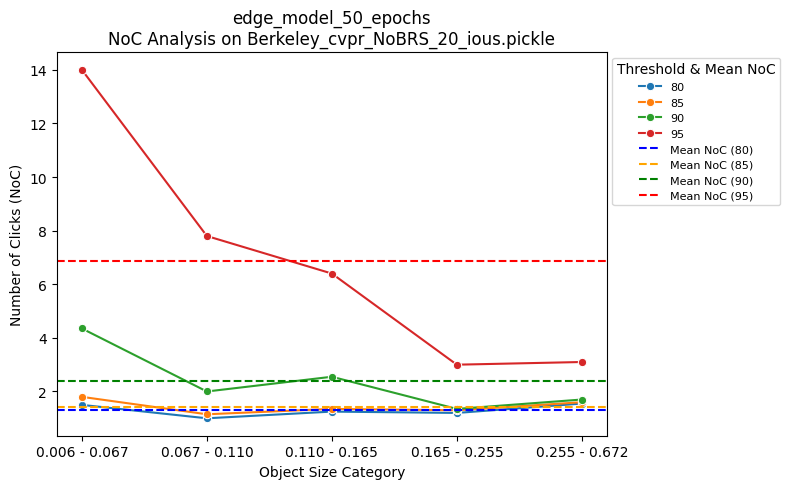

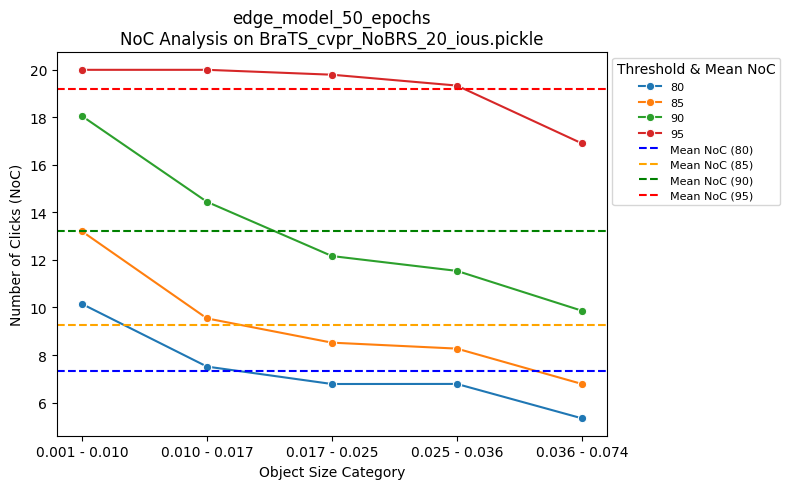

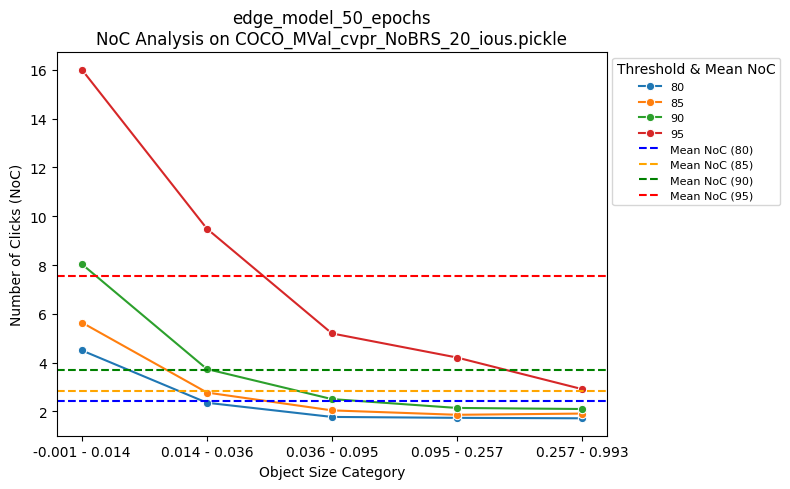

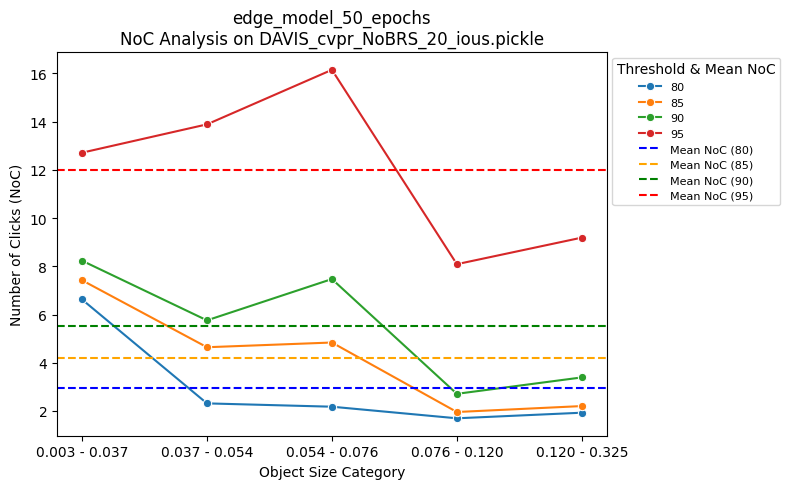

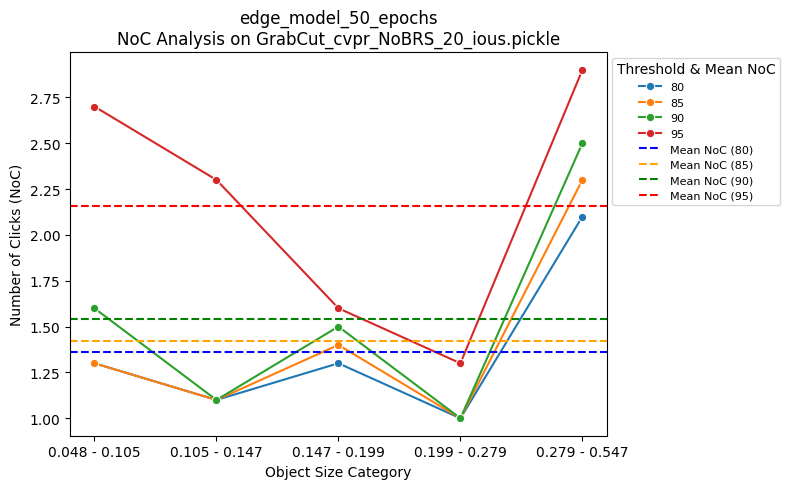

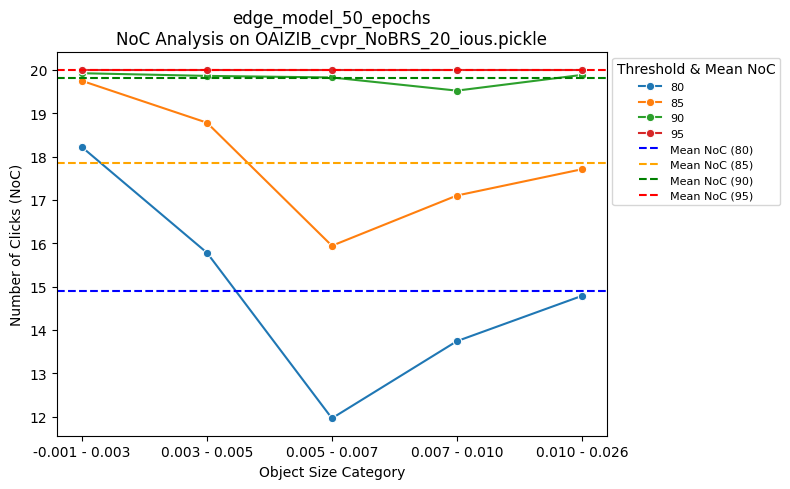

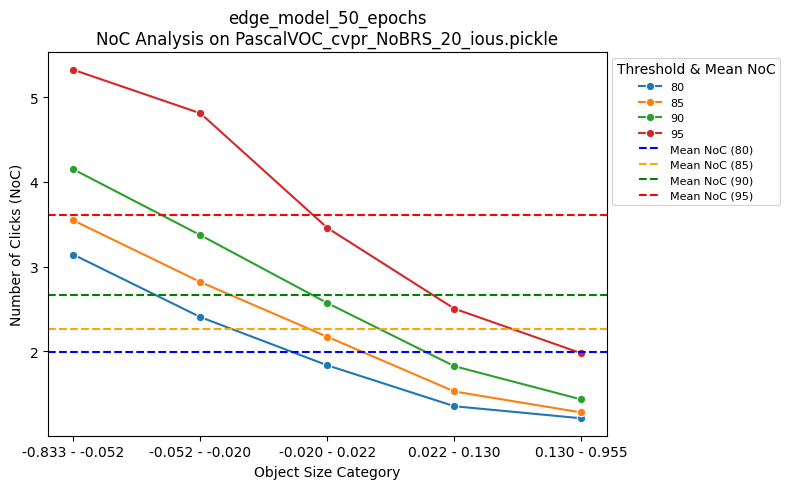

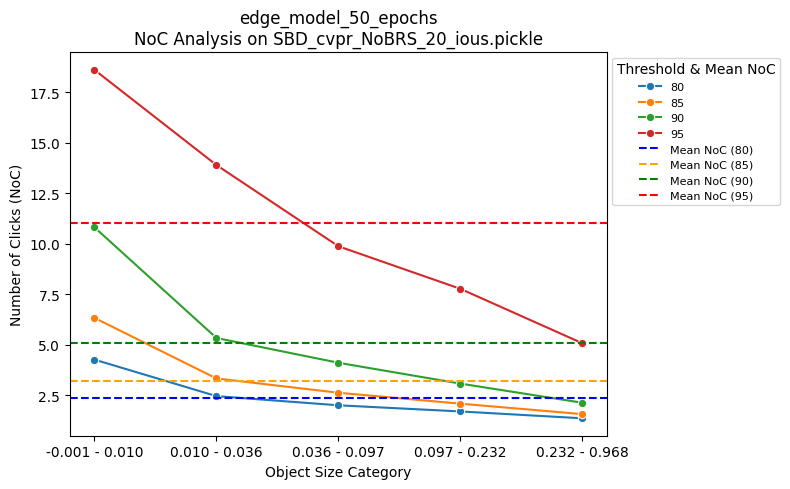

In [ ]:
# metric_type = 'ious'
# arch = 'base_model'
# model = 'edge_model_50_epochs'
# metric_path = f'./{arch}/{model}/metric_analysis'
# filtered_files = [file for file in glob.glob(f'{metric_path}*/*/*{metric_type}.pickle') 
#                   if f'/{metric_type}.pickle' in file or f'_{metric_type}.pickle' in file]
# results = []

# for f in sorted(filtered_files):
#     results.append(analyze(f,num_bin=5))

# noc_report = pd.concat([i[0] for i in results])
# noc_report_by_sizes = pd.concat([i[1] for i in results])

# with pd.ExcelWriter(f'../evaluation/{arch}/{model}/overall.xlsx') as writer:
#     noc_report.to_excel(excel_writer=writer, sheet_name='noc_report', merge_cells=False)
#     noc_report_by_sizes.to_excel(excel_writer=writer,sheet_name='noc_report_by_sizes', merge_cells=False
#     )


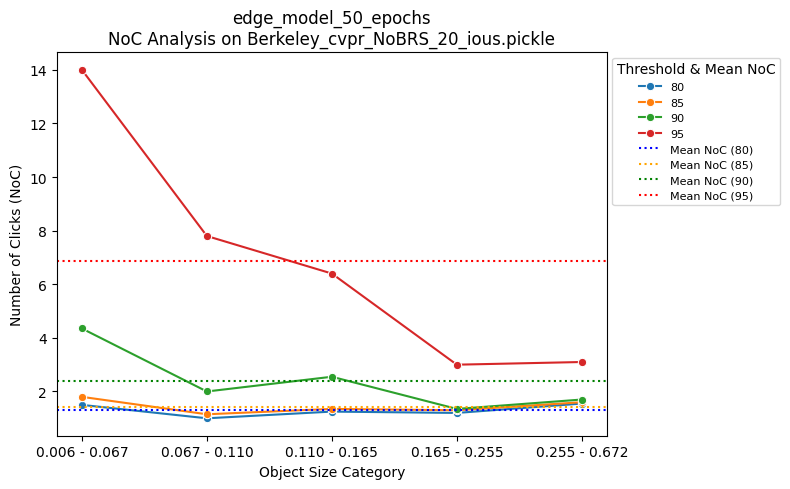

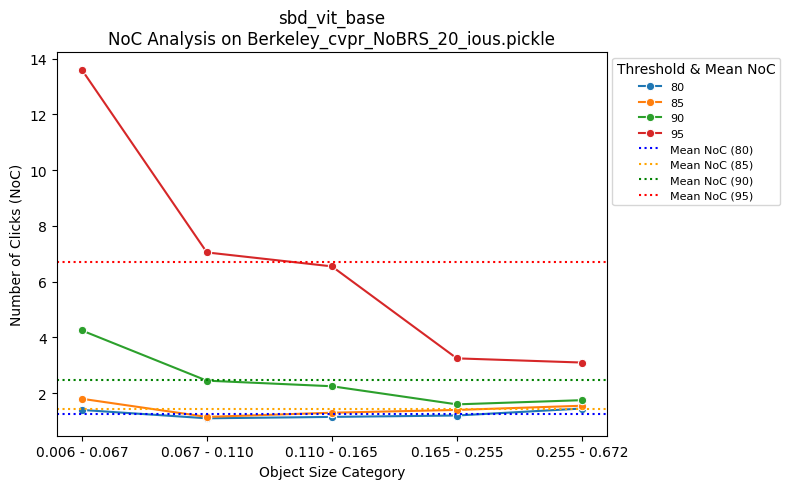

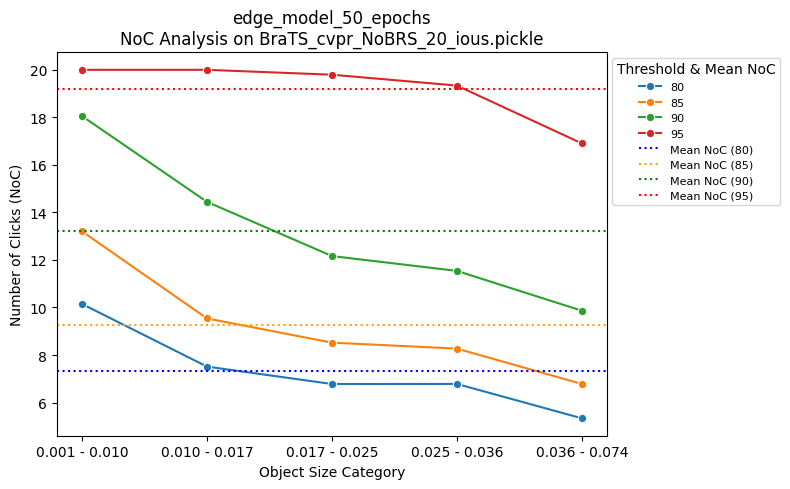

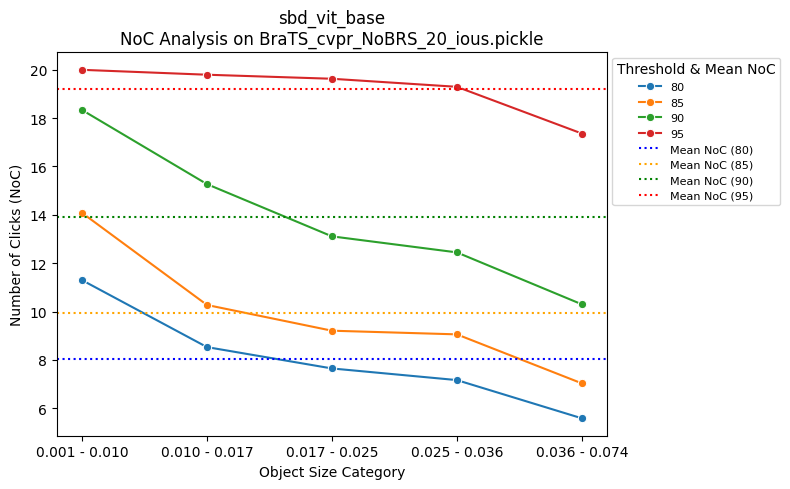

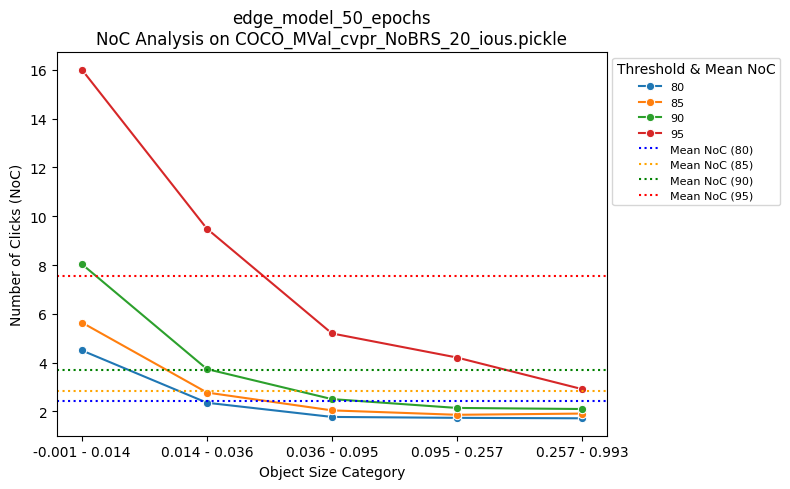

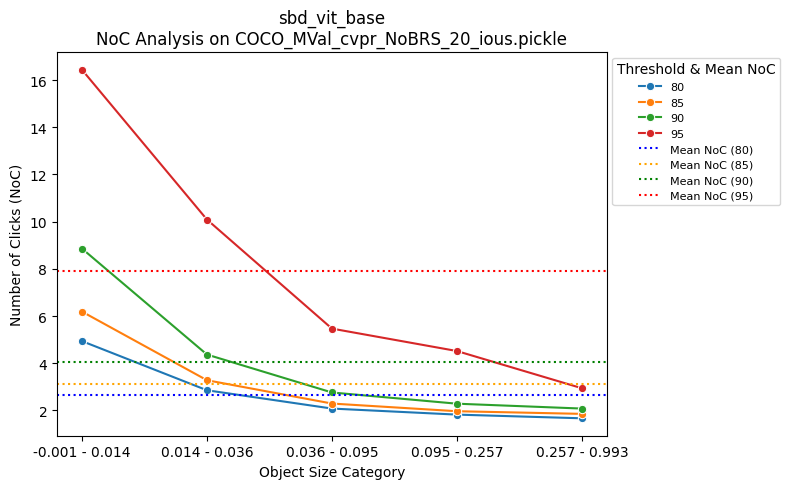

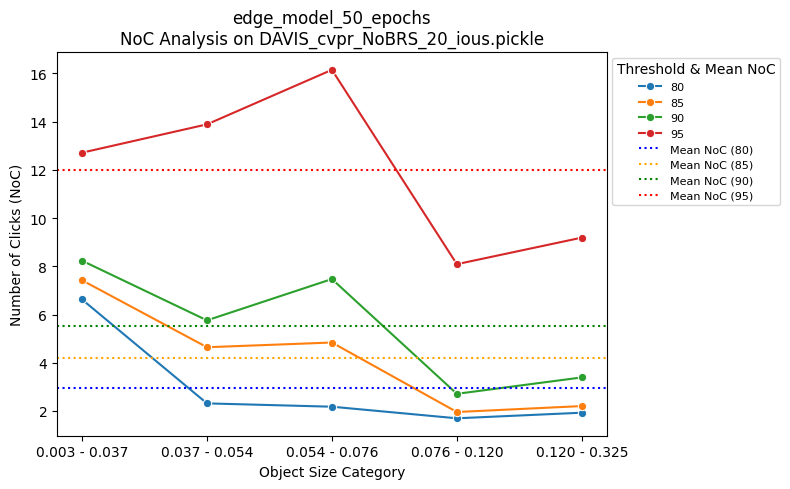

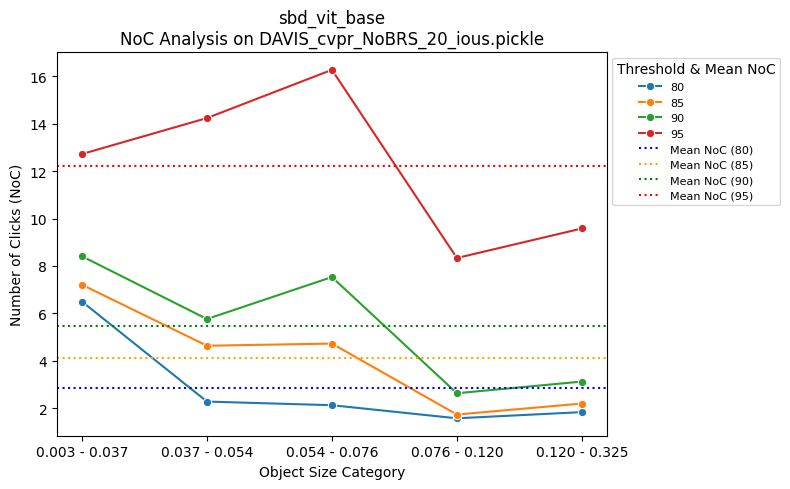

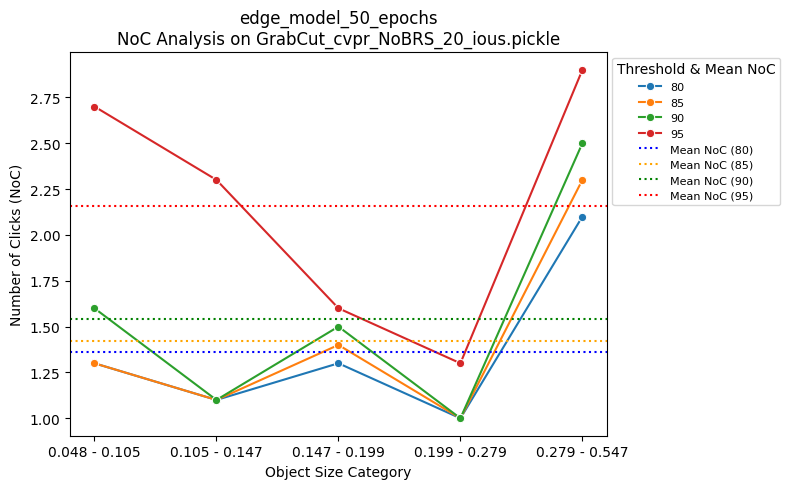

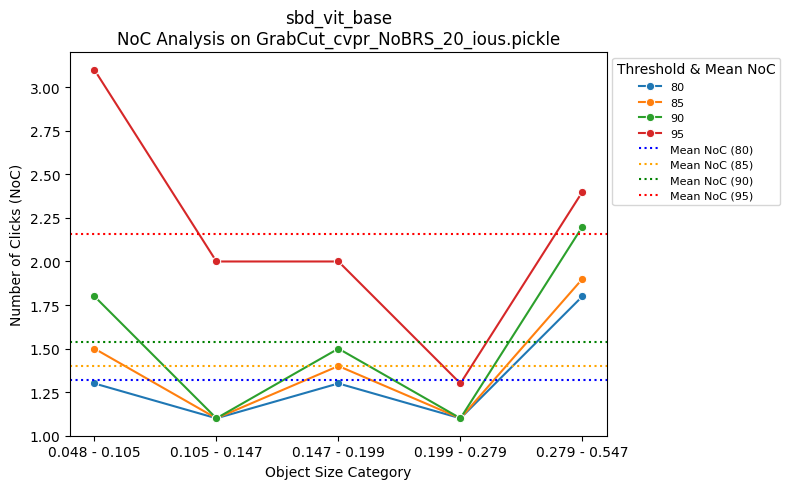

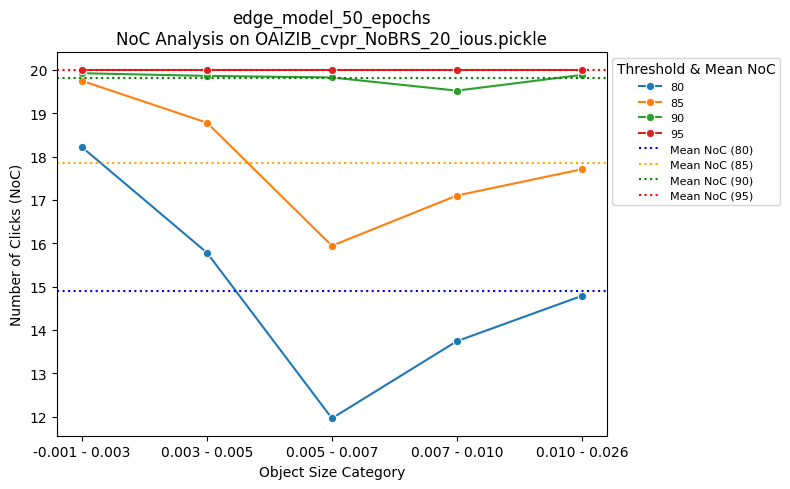

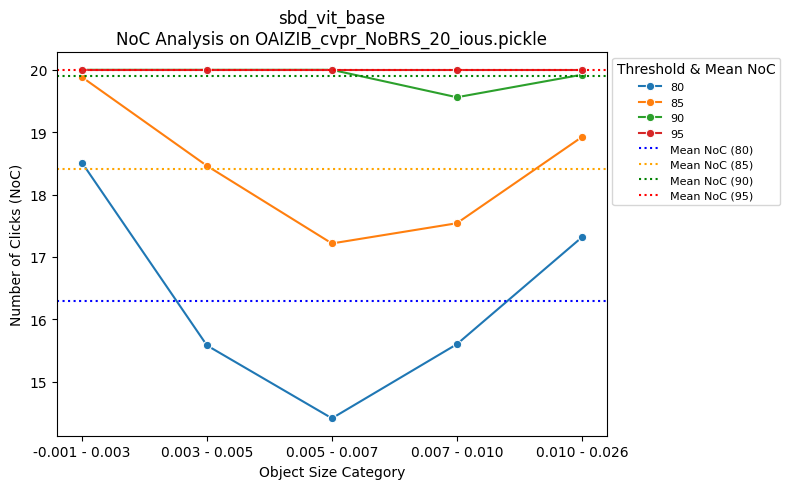

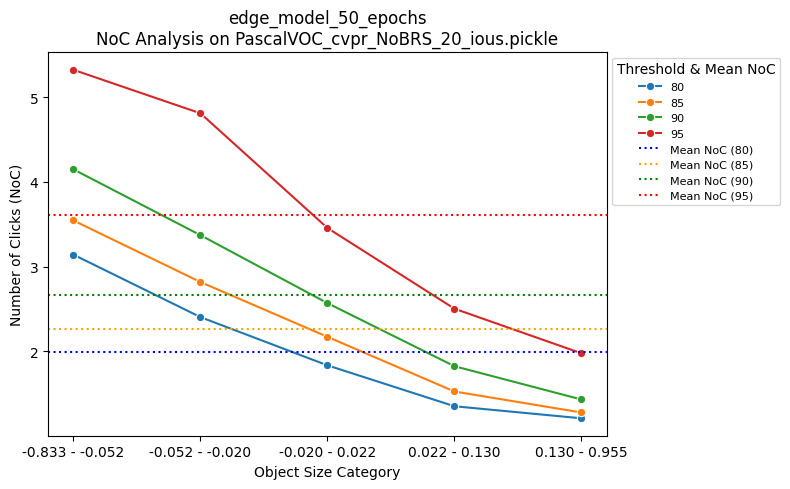

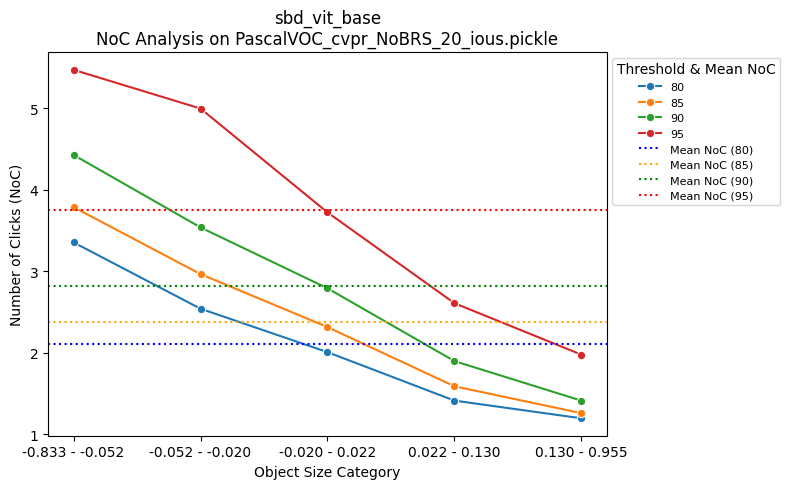

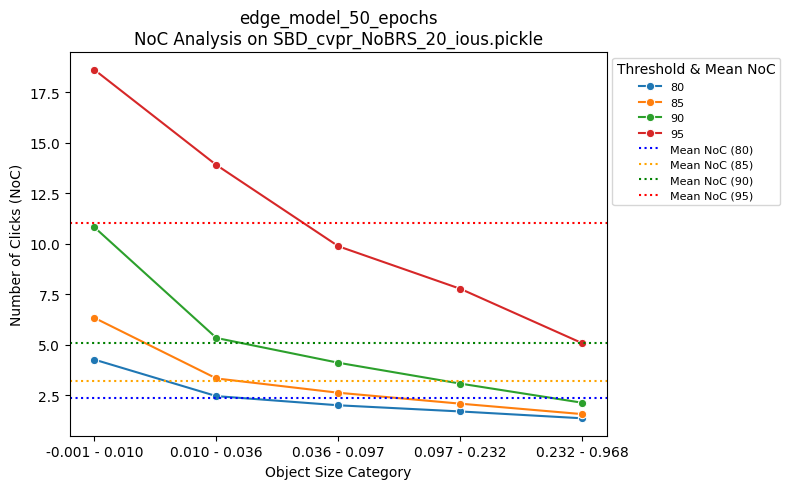

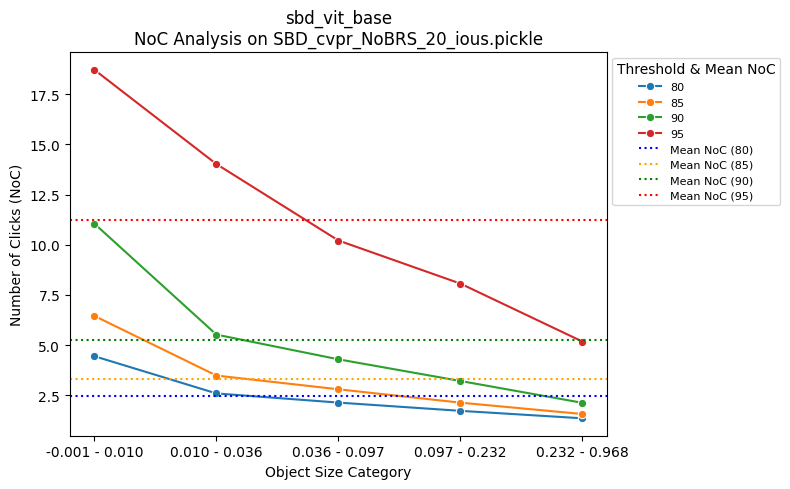

In [28]:
metric_type = 'ious'

sorted_files = sorted(glob.glob(f'./base_model/*/metric_analysis*/*/*{metric_type}.pickle'),key=lambda x: os.path.basename(x))



filtered_files = [file for file in sorted_files
                  if f'/{metric_type}.pickle' in file or f'_{metric_type}.pickle' in file]
results = []

for f in filtered_files:
    results.append(analyze(f,num_bin=5))

noc_report = pd.concat([i[0] for i in results])
noc_report_by_sizes = pd.concat([i[1] for i in results])

with pd.ExcelWriter(f'../evaluation/base_model/overall.xlsx') as writer:
    noc_report.to_excel(excel_writer=writer, sheet_name='noc_report', merge_cells=False)
    noc_report_by_sizes.to_excel(excel_writer=writer,sheet_name='noc_report_by_sizes', merge_cells=False
    )


In [16]:
# metric_type = 'ious'
# metric_path = './base_model/sbd_vit_base/metric_analysis'
# filtered_files = [file for file in glob.glob(f'{metric_path}*/*/*{metric_type}.pickle') 
#                   if f'/{metric_type}.pickle' in file or f'_{metric_type}.pickle' in file]
# results = []
# #'./base_model/edge_model_50_epochs*/*/*.pkl
# #/edge_model_50_epochs_test*/*/*.pickle
# for f in sorted(filtered_files):
#     results.append(analyze(f,num_bin=5))

# noc_report = pd.concat([i[0] for i in results])
# noc_report_by_sizes = pd.concat([i[1] for i in results])

# with pd.ExcelWriter('../experiments/overall.xlsx') as writer:
#     noc_report.to_excel(excel_writer=writer, sheet_name='noc_report', merge_cells=False)
#     noc_report_by_sizes.to_excel(excel_writer=writer,sheet_name='noc_report_by_sizes', merge_cells=False
#     )
